In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [132]:
df = pd.read_csv('../dataset/hdfc_loan_dataset_full_enriched.csv')

In [133]:
df.columns

Index(['Loan_ID', 'Bank', 'Customer_Name', 'Gender', 'Married', 'Dependents',
       'Education', 'Employment_Status', 'Applicant_Income',
       'Coapplicant_Income', 'Loan_Amount', 'Loan_Term_Months',
       'Credit_History', 'Property_Area', 'Age', 'Loan_Status', 'CIBIL_Score',
       'Annual_Household_Income', 'Debt_to_Income_Ratio', 'Purpose_of_Loan',
       'Existing_EMIs', 'Number_of_Previous_Loans', 'Default_History_Count',
       'Employment_Length_Years', 'Business_Type', 'Asset_Value', 'Guarantor',
       'Co-signer_Relationship', 'Monthly_Expense', 'Organization_Type',
       'Region_Branch', 'Mobile_Verified', 'Email_Verified',
       'Institutional_Relationships', 'Application_Text', 'Customer_Feedback',
       'Agent_Notes', 'Loan_to_Annual_Income', 'Customer_Sentiment',
       'Religion', 'State', 'City', 'PIN_Code', 'Aadhaar_Synthetic',
       'Phone_Number', 'Email', 'Occupation'],
      dtype='str')

In [134]:
df.shape

(1000, 47)

In [135]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Loan_ID                      1000 non-null   str    
 1   Bank                         1000 non-null   str    
 2   Customer_Name                1000 non-null   str    
 3   Gender                       1000 non-null   str    
 4   Married                      1000 non-null   str    
 5   Dependents                   1000 non-null   int64  
 6   Education                    1000 non-null   str    
 7   Employment_Status            1000 non-null   str    
 8   Applicant_Income             1000 non-null   int64  
 9   Coapplicant_Income           1000 non-null   int64  
 10  Loan_Amount                  1000 non-null   int64  
 11  Loan_Term_Months             1000 non-null   int64  
 12  Credit_History               1000 non-null   int64  
 13  Property_Area                1

In [136]:
df.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,11.747000,Positive,Hindu,Delhi,Dwarka,857743,694000000000.000000,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,40.381000,Negative,Hindu,Punjab,Ludhiana,863836,633000000000.000000,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,3.082000,Positive,Hindu,Maharashtra,Nagpur,834796,166000000000.000000,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,0.621000,Negative,Hindu,Gujarat,Vadodara,438590,55281832538.000000,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,1.736000,Neutral,Sikh,West Bengal,Kolkata,495224,156000000000.000000,9795137116,harpreet.singh@example.in,Shopkeeper


In [137]:
# set format to avoid exponentional values
pd.set_option('display.float_format', '{:.6f}'.format)
df.describe()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_History,Age,CIBIL_Score,Annual_Household_Income,Debt_to_Income_Ratio,Existing_EMIs,Number_of_Previous_Loans,Default_History_Count,Employment_Length_Years,Asset_Value,Monthly_Expense,Loan_to_Annual_Income,PIN_Code,Aadhaar_Synthetic,Phone_Number
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.849000,42430.057000,9727.114000,2216712.901000,159.132000,0.723000,34.412000,653.013000,625886.052000,148.118157,18173.390000,0.865000,0.147000,2.434000,1908041.686000,23603.427000,10.163103,509976.408000,485321678781.901978,9500192566.020000
std,0.964951,28133.210769,20568.259450,2635020.932201,127.056704,0.447740,8.572616,73.836540,472454.502692,1974.599103,16298.460525,0.911925,0.499641,2.791673,1481451.419823,18054.598235,25.415631,289145.262650,292531093231.043030,287510540.589119
min,0.000000,0.000000,0.000000,1884.000000,12.000000,0.000000,18.000000,384.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003000,622.000000,258955296.000000,9002443236.000000
25%,0.000000,18260.000000,0.000000,372946.500000,36.000000,0.000000,28.000000,605.750000,263952.000000,0.031000,1741.750000,0.000000,0.000000,0.000000,742440.000000,9159.250000,0.645750,263067.500000,219000000000.000000,9254017754.750000
50%,1.000000,40675.500000,0.000000,972046.000000,120.000000,1.000000,35.000000,654.000000,551244.000000,0.332000,16289.500000,1.000000,0.000000,2.000000,1634312.000000,20787.500000,2.309000,517643.500000,473500000000.000000,9498139675.000000
75%,2.000000,61037.250000,7956.500000,3315037.750000,300.000000,1.000000,40.000000,704.000000,856548.000000,0.795000,29718.500000,1.000000,0.000000,3.000000,2726301.500000,33067.750000,8.326750,756922.000000,730000000000.000000,9750462139.750000
max,3.000000,149266.000000,123461.000000,13790960.000000,360.000000,1.000000,66.000000,878.000000,2555340.000000,38342.000000,82436.000000,5.000000,3.000000,15.000000,7742001.000000,97762.000000,269.754000,998910.000000,999000000000.000000,9999101576.000000


In [138]:
# count duplicate records 
df.duplicated().sum()

np.int64(0)

In [139]:
# count null values
df.isnull().sum()

Loan_ID                          0
Bank                             0
Customer_Name                    0
Gender                           0
Married                          0
Dependents                       0
Education                        0
Employment_Status                0
Applicant_Income                 0
Coapplicant_Income               0
Loan_Amount                      0
Loan_Term_Months                 0
Credit_History                   0
Property_Area                    0
Age                              0
Loan_Status                      0
CIBIL_Score                      0
Annual_Household_Income          0
Debt_to_Income_Ratio             0
Purpose_of_Loan                  0
Existing_EMIs                    0
Number_of_Previous_Loans         0
Default_History_Count            0
Employment_Length_Years          0
Business_Type                  799
Asset_Value                      0
Guarantor                        0
Co-signer_Relationship         234
Monthly_Expense     

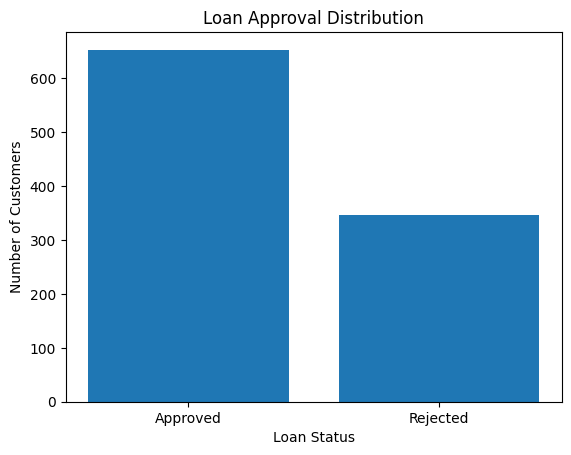

In [140]:
# loan status distribution
loan_status = df['Loan_Status'].value_counts()
plt.bar(loan_status.index, loan_status.values)
plt.title('Loan Approval Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Customers')
plt.savefig('../visuals/loan_approval_distribution.png', bbox_inches='tight')
plt.show()

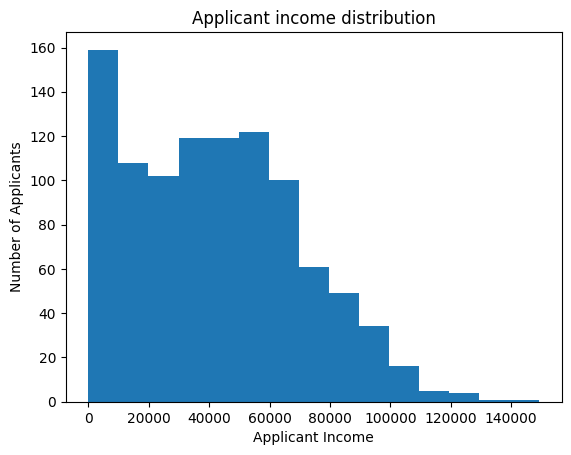

In [141]:
# Applicant income distribution
plt.hist(df['Applicant_Income'], bins=15)
plt.title('Applicant income distribution')
plt.xlabel('Applicant Income')
plt.ylabel('Number of Applicants')
plt.savefig('../visuals/applicat_income_distribution.png', bbox_inches='tight')
plt.show()

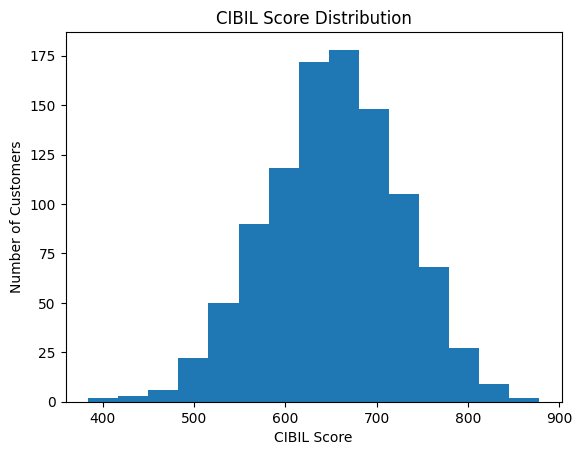

In [142]:
# Cibil score distribution
plt.hist(df['CIBIL_Score'], bins=15)
plt.title('CIBIL Score Distribution')
plt.xlabel('CIBIL Score')
plt.ylabel('Number of Customers')
plt.savefig('../visuals/cibil_score_distribution.png', bbox_inches='tight')
plt.show()

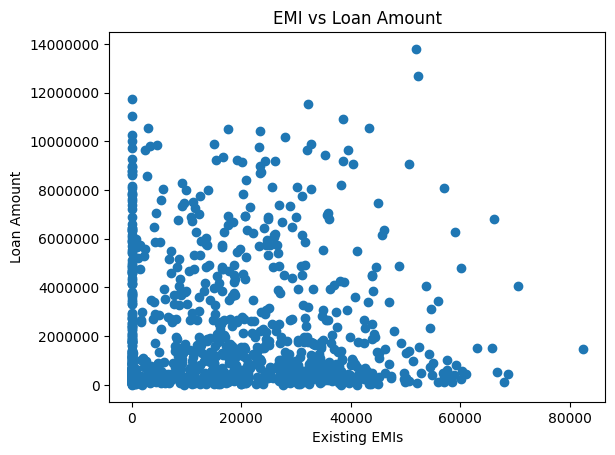

In [159]:
# EMI VS Loan Amount
plt.ticklabel_format(style='plain')
plt.scatter(
    df["Existing_EMIs"],
    df["Loan_Amount"]
)
plt.title("EMI vs Loan Amount")
plt.xlabel("Existing EMIs")
plt.ylabel("Loan Amount")
plt.savefig('../visuals/emi_vs_loan_amount.png', bbox_inches='tight')
plt.show()

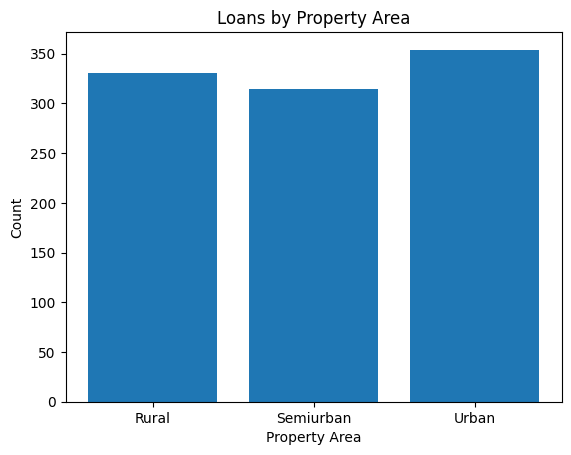

In [160]:
property_counts = (
    df.groupby("Property_Area")["Loan_Status"]
      .count()
)

plt.bar(
    property_counts.index,
    property_counts.values
)

plt.title("Loans by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.savefig('../visuals/loans_by_area.png', bbox_inches='tight')
plt.show()

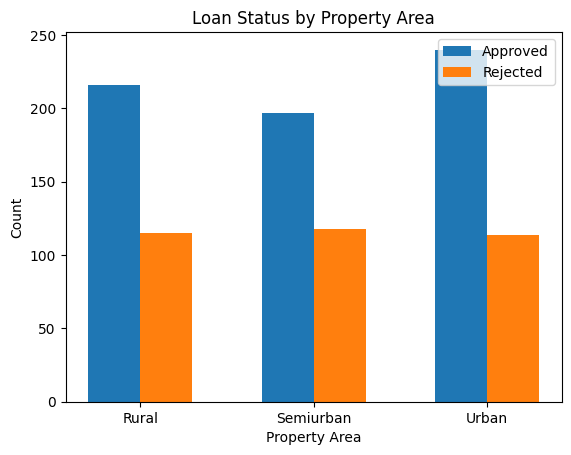

In [185]:
# load approval by property area

loan_status = df.groupby(
    ['Property_Area', 'Loan_Status']
)['Loan_Status'].count().unstack()

x = np.arange(len(loan_status.index))

width = 0.3

plt.bar(
    x - width/2,
    loan_status['Approved'],
    width=width,
    label='Approved'
)

plt.bar(
    x + width/2,
    loan_status['Rejected'],
    width=width,
    label='Rejected'
)

plt.xticks(x, loan_status.index)
plt.title("Loan Status by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Count")

plt.legend(loc="upper right")
plt.savefig('../visuals/loan_status_by_area.png', bbox_inches='tight')
plt.show()

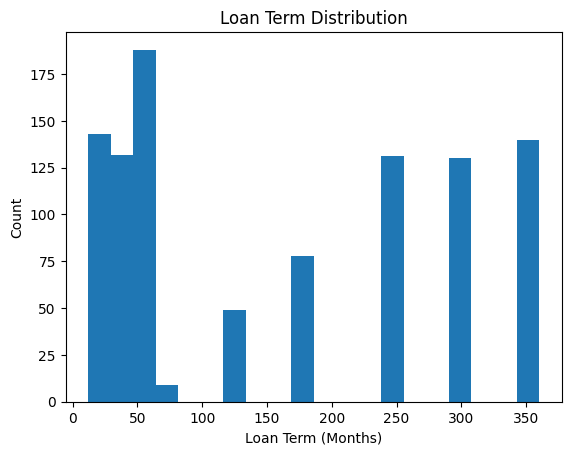

In [162]:
# Loan term Distribution
plt.hist(
    df["Loan_Term_Months"],
    bins=20
)

plt.title("Loan Term Distribution")
plt.xlabel("Loan Term (Months)")
plt.ylabel("Count")
plt.savefig('../visuals/loan_term_distribution.png', bbox_inches='tight')
plt.show()

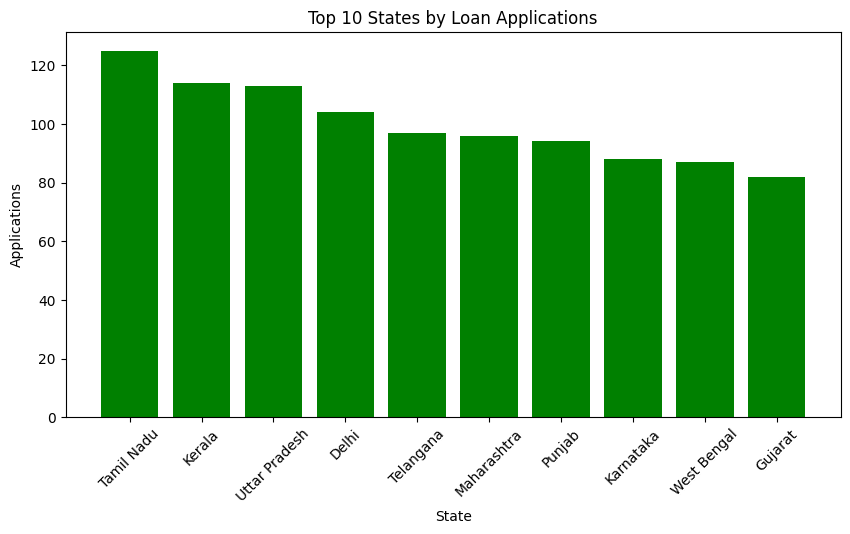

In [163]:
# Top ten states by loan applications
state_counts = df["State"].value_counts().head(10)

plt.figure(figsize=(10,5))

plt.bar(
    state_counts.index,
    state_counts.values,
    color = 'green'
)

plt.title("Top 10 States by Loan Applications")
plt.xlabel("State")
plt.ylabel("Applications")
plt.xticks(rotation=45)
plt.savefig('../visuals/top_10_states_by_loan_applications.png', bbox_inches='tight')
plt.show()

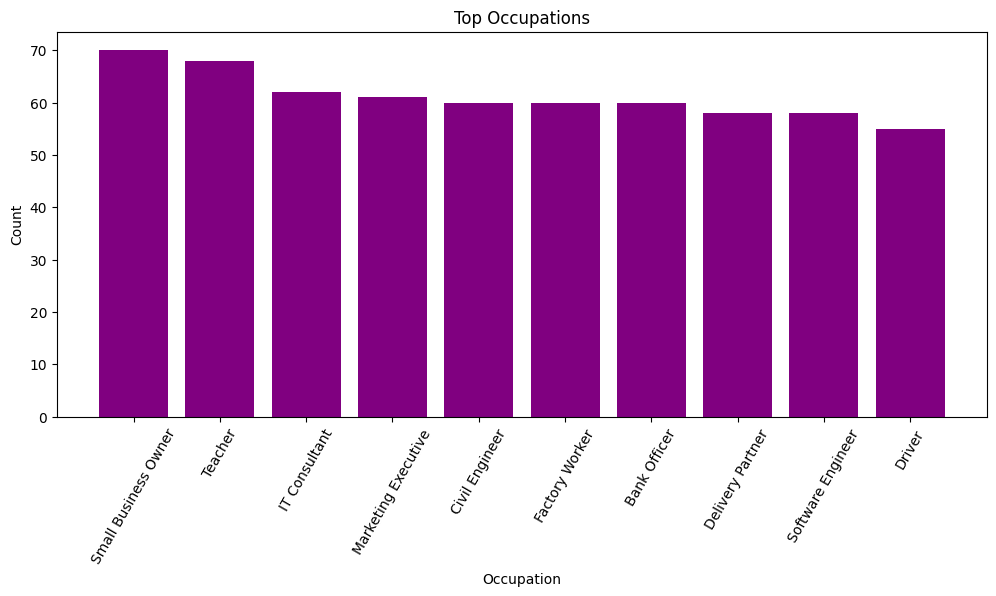

In [164]:
# Top occupations
occupation_counts = (
    df["Occupation"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

plt.bar(
    occupation_counts.index,
    occupation_counts.values,
    color='purple'
)

plt.title("Top Occupations")
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.xticks(rotation=60)
plt.savefig('../visuals/top_10_occupations.png', bbox_inches='tight')

plt.show()

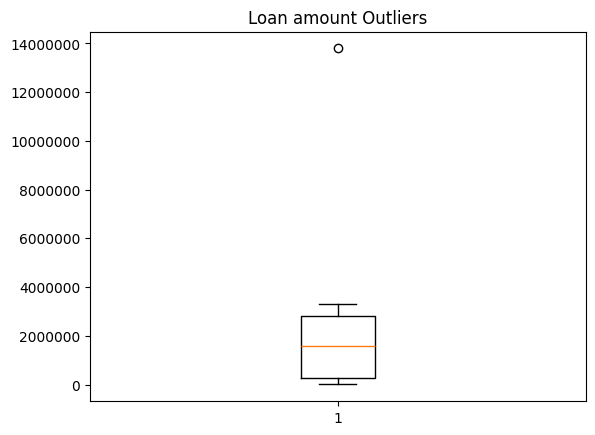

In [167]:
# Format exponential values
plt.ticklabel_format(style='plain')

plt.boxplot(df['Loan_Amount'].describe())
plt.title("Loan amount Outliers")
plt.show()

C:\Users\vilas\AppData\Local\Temp\ipykernel_25408\1868325100.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


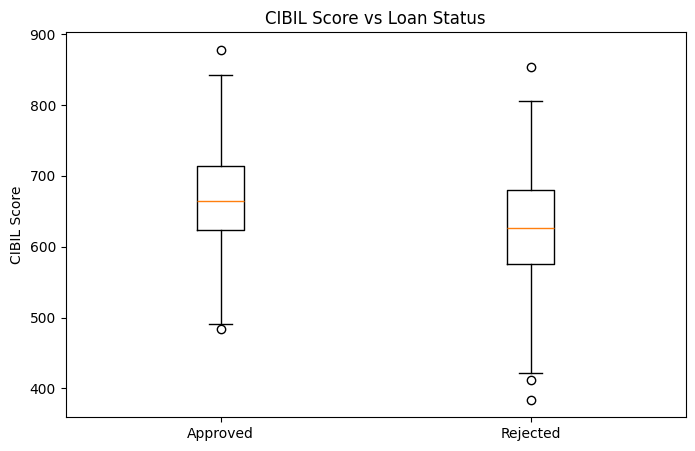

Customers with higher CIBIL scores are more likely to get loan approval.


In [172]:
# CIBIL score VS Loan approval rate
approved = df[
    df["Loan_Status"] == "Approved"
]["CIBIL_Score"]

rejected = df[
    df["Loan_Status"] == "Rejected"
]["CIBIL_Score"]

plt.figure(figsize=(8,5))

plt.boxplot(
    [approved, rejected],
    labels=["Approved", "Rejected"]
)

plt.title("CIBIL Score vs Loan Status")
plt.ylabel("CIBIL Score")

plt.savefig('../visuals/cibil_vs_loan_status.png')
plt.show()

print("Customers with higher CIBIL scores are more likely to get loan approval.")

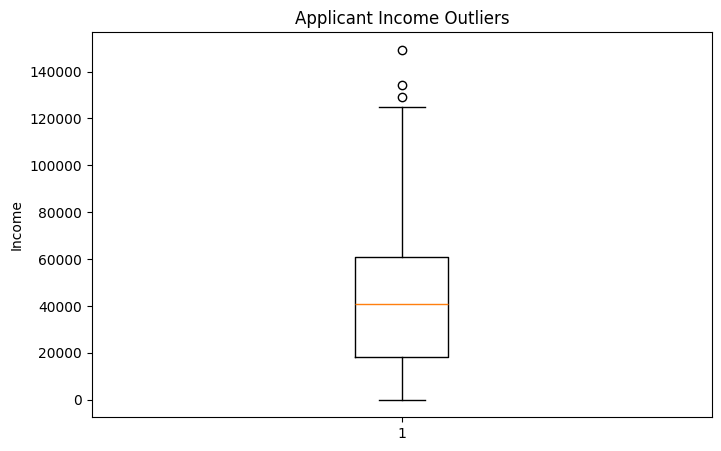

In [173]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Applicant_Income"])
plt.title("Applicant Income Outliers")
plt.ylabel("Income")

plt.savefig('../visuals/applicant_income_outliers.png')
plt.show()

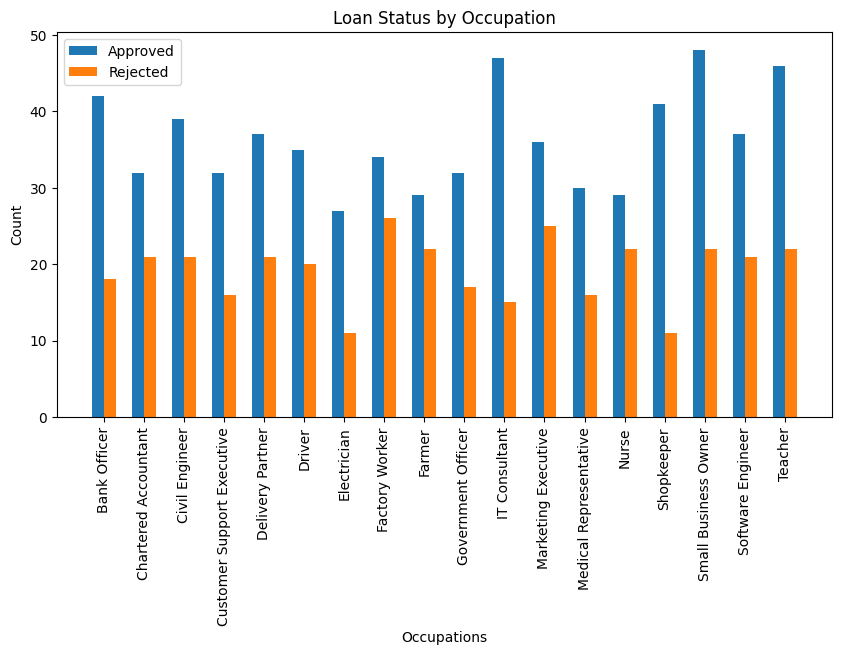

In [182]:
# loan approved by occupation
loan_status = df.groupby(
    ['Occupation', 'Loan_Status']
)['Loan_Status'].count().unstack()

x = np.arange(len(loan_status.index))

width = 0.3
plt.figure(figsize=(10, 5))
plt.bar(
    x - width/2,
    loan_status['Approved'],
    width=width,
    label='Approved'
)

plt.bar(
    x + width/2,
    loan_status['Rejected'],
    width=width,
    label='Rejected'
)

plt.xticks(x, loan_status.index, rotation=90)
plt.title("Loan Status by Occupation")
plt.xlabel("Occupations")

plt.ylabel("Count")

plt.legend()
plt.savefig('../visuals/loan_status_by_occupation.png', bbox_inches='tight')
plt.show()